# **A3 Predicting Car Prices** *ML AUG-2026*

## Submitted By: *Anish Lal Manandhar (st125973)*

**GIT REPO:**   https://github.com/anishDevMage/ML-August-2026-A3-st125973

**APP HOSTED ON:**  http://192.41.170.105:8051/  *(A3 container; the A2 app stays on port 8050)*

**MLFLOW:** experiment `st125973-a3` on http://mlflow.ml.brain.cs.ait.ac.th/ · registered model `st125973-a3-model` (Staging)

### **Pipeline followed in this notebook**

`Load → Clean → EDA (look only) → Label (bin selling_price into 4 classes) → Split (stratified) → Encode + Scale (fit on TRAIN only, transform both) → Model (Task 1 metrics + Task 2 ridge option) → Experiments with stratified K-fold CV, logged to MLflow → refit best on all TRAIN → TEST once → feature importance → export the fitted encoders + scaler + weights for the app → register the best model (Task 3)`

| Assignment part | Where |
|---|---|
| Task 1 – accuracy, precision, recall, F1, macro & weighted averages, comparison with sklearn, *support* | sections **Modeling** → **Task 1** |
| Task 2 – Ridge (L2) logistic regression, user chooses to use it or not | `RidgePenalty`, `use_penalty=`, `RidgeLogisticRegression` → **Task 2** |
| Task 3 – MLflow server, model registry, CI/CD | **Experiments (MLflow)**, **Export for the app**, **Register** and the `app/` folder, `.github/workflows/`, `README.md` |

### **Data Load**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

*Data Import*

In [2]:
df = pd.read_csv("Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.shape

(8128, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [5]:
df['selling_price'].describe()

count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

### **Data Cleaning**
##### Few Initial Sections of Data Cleaning are performed similar to the previous assignments also since the same dataset is being used

##### *Duplicate check and drop*

In [6]:
# Check and delete for duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()
df.shape

1202


(6926, 13)

In [7]:
# REMOVING ROW VALUES (same as A1/A2)
# CNG / LPG cars measure mileage in km/kg (not kmpl like Petrol / Diesel) -> not comparable
# Test Drive Cars are almost-new cars sold by dealers -> they would distort the prices
df = df[~df['fuel'].isin(['CNG', 'LPG'])]
df = df[df['owner'] != 'Test Drive Car']
df.shape

(6827, 13)

In [8]:
df[['mileage', 'engine', 'max_power']].dtypes

mileage      str
engine       str
max_power    str
dtype: object

Type Casting

In [9]:
# keep the number, drop the unit: '23.4 kmpl' -> 23.4, '1248 CC' -> 1248.0, '74 bhp' -> 74.0
df['mileage'] = df['mileage'].str.split().str[0].astype(float)
df['engine'] = df['engine'].str.split().str[0].astype(float)
df['max_power'] = df['max_power'].str.split().str[0].astype(float)

Drop Torque Column

In [10]:
# DROPPING FEATURES: torque mixes units (Nm, kgm, rpm ranges) -> dropped as in A1/A2
df.drop('torque', axis=1, inplace=True)

*Fill Data*

In [11]:
# brand = first word of the car name ('Maruti Swift Dzire VDI' -> 'Maruti')
df['brand'] = df['name'].str.split().str[0]
df['brand'] = df['brand'].fillna('Unknown')
df.drop(columns=['name'], inplace=True)

In [12]:
print("\nUnique brands in the dataset:")
print(df['brand'].unique())


Unique brands in the dataset:
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']


##### *Null check and drop*

In [13]:
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
brand              0
dtype: int64

In [14]:
# SMALL PERCENTAGE DELETED
rows_with_nan = df[['mileage', 'engine', 'max_power', 'seats']].isna().any(axis=1)
print(f"rows with a missing value: {rows_with_nan.sum()} of {len(df)} ({rows_with_nan.mean() * 100:.1f}%)")

df = df.dropna(subset=['mileage', 'engine', 'max_power', 'seats'])
df.isnull().sum()

rows with a missing value: 201 of 6827 (2.9%)


year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 6626 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6626 non-null   int64  
 1   selling_price  6626 non-null   int64  
 2   km_driven      6626 non-null   int64  
 3   fuel           6626 non-null   str    
 4   seller_type    6626 non-null   str    
 5   transmission   6626 non-null   str    
 6   owner          6626 non-null   str    
 7   mileage        6626 non-null   float64
 8   engine         6626 non-null   float64
 9   max_power      6626 non-null   float64
 10  seats          6626 non-null   float64
 11  brand          6626 non-null   object 
dtypes: float64(4), int64(3), object(1), str(4)
memory usage: 673.0+ KB


## Explanatory Data Analysis (EDA)
*Looking only – nothing in the data is changed in this section.*

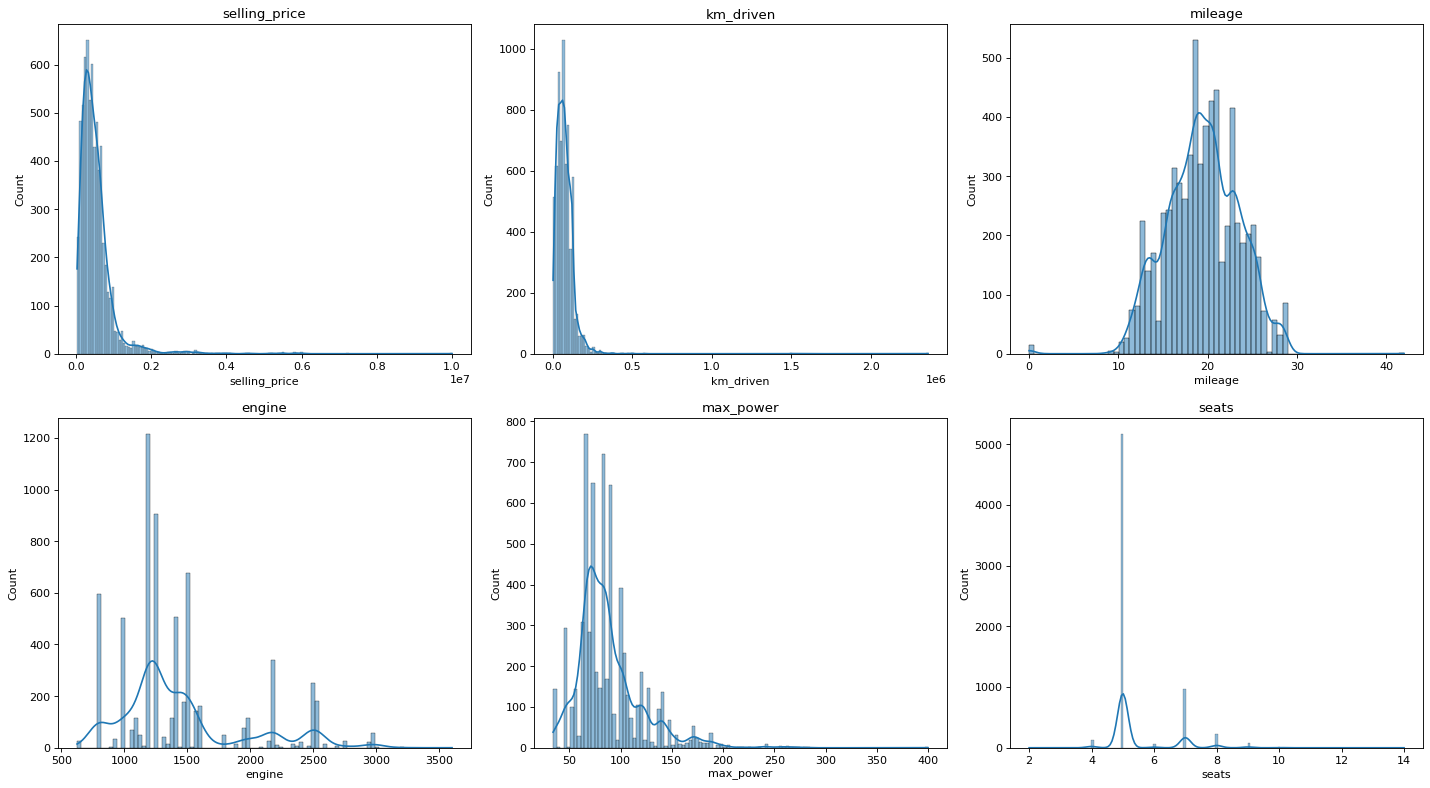

In [16]:
fig , axes = plt.subplots(2,3, figsize=(18,10))
axes = axes.flatten()

cols = [ 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats' ]

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

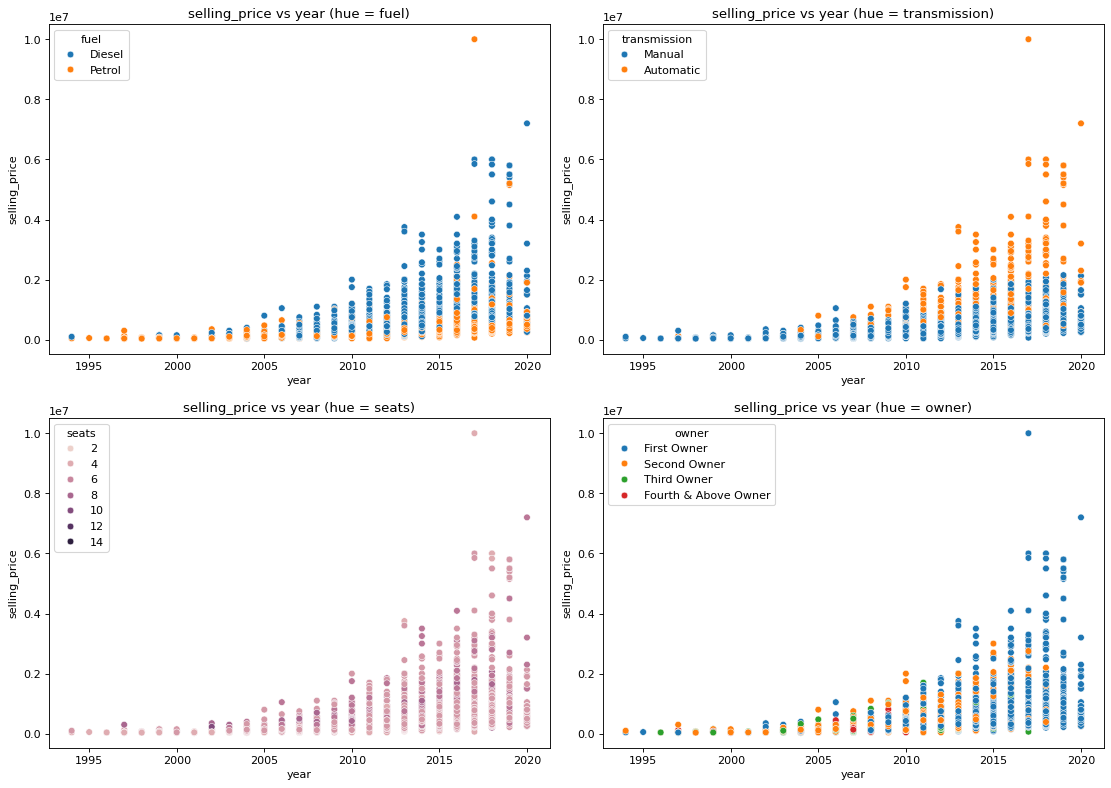

In [17]:
# selling_price vs year, coloured by one column per subplot
# (one y-variable per figure: drawing selling_price, km_driven and mileage on the same axes mixes three scales)
fig, axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()

hue_cols = ['fuel', 'transmission', 'seats', 'owner']

for i, hue_col in enumerate(hue_cols):
    sns.scatterplot(data=df, x='year', y='selling_price', hue = hue_col, ax=axes[i])
    axes[i].set_title(f"selling_price vs year (hue = {hue_col})")

plt.tight_layout()
plt.show()

**What the EDA tells us:** `selling_price`, `km_driven` and `max_power` are right-skewed (a few very expensive / very high values), newer cars sell for more, and Automatic / Diesel cars sit higher in price. Because the target becomes *4 price classes*, the skew of the price no longer matters for the model; the classes are defined with quartiles in the next step.

## BINNING
#### Binning Selling Price

The label (y) is created here: `selling_price` → 4 buckets `0, 1, 2, 3` with `pd.cut()`.
* The edges are the **quartiles** (25 %, 50 % = median, 75 %), so each class holds about a quarter of the cars → a balanced 4-class problem. The mean would be pulled up by the few expensive cars, and the mode makes no sense for edges.
* This defines the target, so it is done once on the cleaned data **before** the split; train and test then use identical price ranges. The edges are saved and reused by the web app to show the price range of a predicted class.

In [18]:
# using pd.cut()
selling_price_bins = [
    df['selling_price'].min() - 1,
    df['selling_price'].quantile(0.25),
    df['selling_price'].quantile(0.5),
    df['selling_price'].quantile(0.75),
    df['selling_price'].max()
]

bin_labels = [0,1,2,3]

# pd.cut returns a 'category' column -> .astype(int) makes it a normal integer label
df['price_class'] = pd.cut(df['selling_price'], bins = selling_price_bins, labels = bin_labels, include_lowest = True).astype(int)

print("bin edges:", [float(b) for b in selling_price_bins])
print(df['price_class'].value_counts().sort_index())

bin edges: [29998.0, 250000.0, 422000.0, 650000.0, 10000000.0]
price_class
0    1705
1    1608
2    1771
3    1542
Name: count, dtype: int64


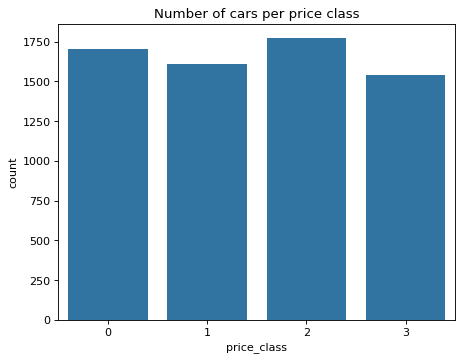

In [19]:
sns.countplot(data=df, x='price_class')
plt.title("Number of cars per price class")
plt.show()

## Split Train / Test

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X = df.drop(columns=['price_class', 'selling_price'])
y = df['price_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42
                                                   , stratify = y) # KEEPS THE CLASSIFICATIONS EVEN

print("CHECKING SHAPES: ", X_train.shape, X_test.shape)
print("\n")
print("CHECKING FOR ENCODING: ", X_train.dtypes.value_counts())
print("\n")
print("CLASS SHARE (train vs test):")
print(pd.DataFrame({'train': y_train.value_counts(normalize=True).sort_index(),
                    'test': y_test.value_counts(normalize=True).sort_index()}).round(3))

CHECKING SHAPES:  (5300, 11) (1326, 11)


CHECKING FOR ENCODING:  str        4
float64    4
int64      2
object     1
Name: count, dtype: int64


CLASS SHARE (train vs test):
             train   test
price_class              
0            0.257  0.257
1            0.243  0.243
2            0.267  0.267
3            0.233  0.233


In [22]:
# Raw copies (before any encoding) -> used at the end to check that the web app's
# preprocessing gives exactly the same predictions as this notebook
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Defaults for inputs a user leaves empty in the web app.
# They are learned from the TRAINING set only (median for numbers, mode for categories).
train_defaults = {}
for col in ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']:
    train_defaults[col] = float(X_train[col].median())
for col in ['fuel', 'seller_type', 'transmission', 'owner', 'brand']:
    train_defaults[col] = X_train[col].mode()[0]
train_defaults

{'year': 2014.0, 'km_driven': 68000.0, 'mileage': 19.4, 'engine': 1248.0, 'max_power': 81.86, 'seats': 5.0, 'fuel': 'Diesel', 'seller_type': 'Individual', 'transmission': 'Manual', 'owner': 'First Owner', 'brand': 'Maruti'}

## **Encoding**
Everything below is done **after** the split. Anything that *learns* from data (`LabelEncoder`, `OneHotEncoder`, `StandardScaler`) is **fit on `X_train` only** and then only **transforms** `X_test`. Fixed `.map()` dictionaries learn nothing, so they are simply applied to both sets.

In [23]:
X_train.dtypes

year              int64
km_driven         int64
fuel                str
seller_type         str
transmission        str
owner               str
mileage         float64
engine          float64
max_power       float64
seats           float64
brand            object
dtype: object

#### **Encoding Column: Owner**

In [24]:
print(X_train["owner"].unique())
print(X_test["owner"].unique())

<StringArray>
['Fourth & Above Owner', 'First Owner', 'Second Owner', 'Third Owner']
Length: 4, dtype: str
<StringArray>
['First Owner', 'Second Owner', 'Fourth & Above Owner', 'Third Owner']
Length: 4, dtype: str


In [25]:
# ordinal: First < Second < Third < Fourth -> keep the order with a fixed mapping
owner_mapping = {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3,
       'Fourth & Above Owner': 4}

X_train['owner'] = X_train['owner'].map(owner_mapping)
X_test['owner'] = X_test['owner'].map(owner_mapping)
print(X_train["owner"].isna().sum() , X_test["owner"].isna().sum())   # 0 0 -> every value was in the mapping

0 0


#### **Encoding Column: Transmission**

In [26]:
X_train['transmission'].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [27]:
transmission_mapping = { 'Manual': 1, 'Automatic': 0 }

X_train["transmission"] = X_train['transmission'].map(transmission_mapping)
X_test["transmission"] = X_test['transmission'].map(transmission_mapping)

print(X_train["transmission"].isna().sum(), X_test["transmission"].isna().sum())

0 0


#### **Encoding Column: Fuel**

In [28]:
fuel_mapping = { 'Petrol': 0, 'Diesel': 1 }

X_train["fuel"] = X_train['fuel'].map(fuel_mapping)
X_test["fuel"] = X_test['fuel'].map(fuel_mapping)

print(X_train["fuel"].isna().sum(), X_test["fuel"].isna().sum())

0 0


In [29]:
print(X_train['fuel'].unique())
print(X_test['fuel'].unique())

[0 1]
[0 1]


### **Label Encoding**

In [30]:
from sklearn.preprocessing import LabelEncoder

#### **Encoding Column: Seller Type**
`LabelEncoder` learns `classes_` (sorted A–Z) from the training set: Dealer → 0, Individual → 1, Trustmark Dealer → 2. This is the encoding used in A1/A2. *Note:* seller_type has no natural order, so one-hot encoding (like brand below) would be the stricter choice for a linear model; label encoding is kept here to stay consistent with the previous assignments.

In [31]:
seller_type_le = LabelEncoder()

seller_type_le.fit(X_train['seller_type'])                                   # learn classes_ from TRAIN
X_train['seller_type'] = seller_type_le.transform(X_train['seller_type'])
X_test['seller_type'] = seller_type_le.transform(X_test['seller_type'])      # transform only

print("classes_:", seller_type_le.classes_)
print(X_train['seller_type'].isna().sum(), X_test['seller_type'].isna().sum())
print(X_train['seller_type'].unique(), X_test['seller_type'].unique())

classes_: ['Dealer' 'Individual' 'Trustmark Dealer']
0 0
[1 0 2] [1 0 2]


### **One Hot Encoding**

In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
# a brand that is in the test set but never in the training set cannot get its own column
unseen_brands = set(X_test['brand']) - set(X_train['brand'])
print("brands only in the test set:", unseen_brands)

brands only in the test set: {'Ashok'}


In [34]:
# fit on TRAIN only: the encoder learns the list of brands -> brandOneEncoder.categories_
# handle_unknown='ignore': an unseen brand becomes a row of all zeros instead of an error
# (with the default handle_unknown='error', transforming X_test crashes because of the brand printed above)
brandOneEncoder = OneHotEncoder(sparse_output=False, dtype=int, handle_unknown='ignore')
brandOneEncoder.fit(X_train[['brand']])
cols = brandOneEncoder.get_feature_names_out(['brand'])     # 'brand_' + category
print(cols)

# TRAIN: transform -> wrap the 0/1 array in a DataFrame with the SAME index -> glue it next to the other columns
arr_train = brandOneEncoder.transform(X_train[['brand']])
dummies_train = pd.DataFrame(arr_train, columns = cols, index = X_train.index)
X_train = pd.concat([X_train.drop(columns = 'brand'), dummies_train], axis = 1)

# TEST: transform only (never fit again) -> same columns, same order
arr_test = brandOneEncoder.transform(X_test[['brand']])
dummies_test = pd.DataFrame(arr_test, columns = cols, index = X_test.index)
X_test = pd.concat([X_test.drop(columns = 'brand'), dummies_test], axis = 1)

print("\nshapes:", X_train.shape, X_test.shape)
print("same columns in the same order:", list(X_train.columns) == list(X_test.columns))
print("missing values:", X_train.isna().sum().sum(), X_test.isna().sum().sum())

['brand_Ambassador' 'brand_Audi' 'brand_BMW' 'brand_Chevrolet'
 'brand_Daewoo' 'brand_Datsun' 'brand_Fiat' 'brand_Force' 'brand_Ford'
 'brand_Honda' 'brand_Hyundai' 'brand_Isuzu' 'brand_Jaguar' 'brand_Jeep'
 'brand_Kia' 'brand_Land' 'brand_Lexus' 'brand_MG' 'brand_Mahindra'
 'brand_Maruti' 'brand_Mercedes-Benz' 'brand_Mitsubishi' 'brand_Nissan'
 'brand_Opel' 'brand_Renault' 'brand_Skoda' 'brand_Tata' 'brand_Toyota'
 'brand_Volkswagen' 'brand_Volvo']

shapes: (5300, 40) (1326, 40)
same columns in the same order: True
missing values: 0 0


In [35]:
X_train.head()

,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand_Ambassador,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
126,2008,65000,0,1,1,4,19.70,796.0,46.30,5.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
773,2016,70000,0,1,1,1,23.95,998.0,67.05,5.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1771,2017,20000,0,1,1,1,18.60,1197.0,81.83,5.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6523,2009,120000,0,1,1,2,16.80,1497.0,116.30,5.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6831,2011,50000,0,1,1,1,15.50,1799.0,132.00,5.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

# Deciding on which cols to scale: the continuous ones (the 0/1 and small integer codes are left as they are)
scal_col = ['year', 'km_driven', 'mileage', 'engine', 'max_power']
X_train[scal_col].describe()

,year,km_driven,mileage,engine,max_power
count,5300.000000,5.300000e+03,5300.000000,5300.000000,5300.000000
mean,2013.620566,7.344786e+04,19.440509,1435.910189,88.032613
std,3.874712,5.291080e+04,4.003057,496.991643,31.806967
min,1994.000000,1.000000e+03,0.000000,624.000000,34.200000
25%,2011.000000,3.800000e+04,16.800000,1197.000000,68.000000
50%,2014.000000,6.800000e+04,19.400000,1248.000000,81.860000
75%,2017.000000,1.000000e+05,22.320000,1498.000000,100.000000
max,2020.000000,1.500000e+06,42.000000,3604.000000,400.000000


Scaling X_train and X_test

In [37]:
scaler = StandardScaler()

X_train[scal_col] = scaler.fit_transform(X_train[scal_col])   # fit: learn mean_ and scale_ from TRAIN, then transform
X_test[scal_col] = scaler.transform(X_test[scal_col])         # transform only -> the test set uses the TRAIN mean / std

print("learned mean_ :", scaler.mean_.round(2))
print("learned scale_:", scaler.scale_.round(2))

learned mean_ : [2.013620e+03 7.344786e+04 1.944000e+01 1.435910e+03 8.803000e+01]
learned scale_: [3.870000e+00 5.290581e+04 4.000000e+00 4.969400e+02 3.180000e+01]


In [38]:
# train: mean 0 and std 1 exactly; test: close to 0 and 1 but not exactly, because it was scaled with the TRAIN numbers (correct!)
# km_driven's test std is larger: the test set contains the car with 2,360,457 km (z = 43)
pd.DataFrame({'train mean': X_train[scal_col].mean(), 'train std': X_train[scal_col].std(ddof=0),
              'test mean': X_test[scal_col].mean(), 'test std': X_test[scal_col].std(ddof=0)}).round(3)

,train mean,train std,test mean,test std
year,-0.0,1.0,-0.013,1.031
km_driven,0.0,1.0,-0.003,1.476
mileage,-0.0,1.0,-0.005,1.011
engine,0.0,1.0,-0.004,0.976
max_power,-0.0,1.0,0.005,0.980


#### Outliers

year: 40 outliers (0.75%)
km_driven: 128 outliers (2.42%)
mileage: 12 outliers (0.23%)
engine: 971 outliers (18.32%)
max_power: 240 outliers (4.53%)


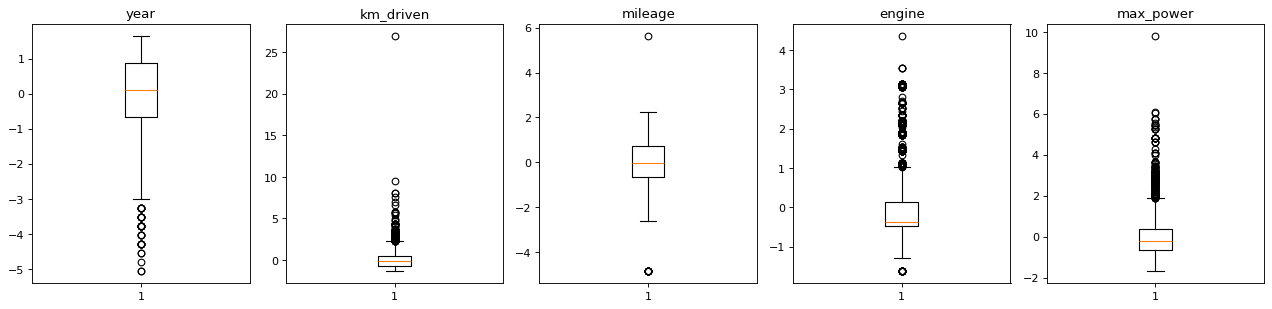

In [39]:
fig, axes = plt.subplots(1, len(scal_col), figsize=(16, 4))

for i, col in enumerate(scal_col):
    bp = axes[i].boxplot(X_train[col])
    axes[i].set_title(col)

    # 'fliers' = the points matplotlib drew as outliers
    n_outliers = len(bp['fliers'][0].get_ydata())
    percent = round(n_outliers / len(X_train[col]) * 100, 2)
    print(f"{col}: {n_outliers} outliers ({percent}%)")

plt.tight_layout()
plt.show()

In [40]:
# Count outliers per column using the standard IQR method

def outlier_count(col, data=X_train):
    q75, q25 = np.percentile(data[col], [75, 25])
    iqr = q75 - q25
    min_val = q25 - (iqr * 1.5)
    max_val = q75 + (iqr * 1.5)
    count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    percent = round(count / len(data[col]) * 100, 2)
    if count > 0:
        print("\n" + 15*'-' + col + 15*'-' + "\n")
        print('Number of outliers: {}'.format(count))
        print('Percent of data that is outlier: {}%'.format(percent))

for col in scal_col:
    outlier_count(col)


---------------year---------------

Number of outliers: 40
Percent of data that is outlier: 0.75%

---------------km_driven---------------

Number of outliers: 128
Percent of data that is outlier: 2.42%

---------------mileage---------------

Number of outliers: 12
Percent of data that is outlier: 0.23%

---------------engine---------------

Number of outliers: 971
Percent of data that is outlier: 18.32%

---------------max_power---------------

Number of outliers: 240
Percent of data that is outlier: 4.53%


**Decision: the outliers are kept.** They are real cars (large engines, powerful and luxury brands, very old or heavily driven cars), not typing errors. `engine` shows ~18 % "outliers" only because most cars have 1.2–1.5 L engines, so the IQR is narrow. Removing them would delete most of the expensive (class 3) examples, and the features are already standardised for gradient descent.

## Modeling
### Preparing X and Y for the from-scratch model
Same steps as *02 - Multinomial Logistic Regression.ipynb*: numpy arrays, an **intercept** column of 1s, and **Y one-hot** with shape `(m, k)`.

In [41]:
import time
from sklearn.metrics import classification_report

In [42]:
feature_names = X_train.columns.tolist()        # 40 columns after encoding (the app needs this exact order)

X_train_arr = X_train.to_numpy(dtype=float)
X_test_arr = X_test.to_numpy(dtype=float)

# add intercept to our X
intercept = np.ones((X_train_arr.shape[0], 1))
X_train_arr = np.concatenate((intercept, X_train_arr), axis=1)
intercept = np.ones((X_test_arr.shape[0], 1))
X_test_arr = np.concatenate((intercept, X_test_arr), axis=1)

y_train_arr = y_train.to_numpy()
y_test_arr = y_test.to_numpy()

print("X_train:", X_train_arr.shape, " X_test:", X_test_arr.shape)

X_train: (5300, 41)  X_test: (1326, 41)


In [43]:
# y train is now (m,k)
k = len(np.unique(y_train_arr))   # no. of classes (4)
m = X_train_arr.shape[0]          # no. of samples
n = X_train_arr.shape[1]          # no. of features + intercept (41)
Y_train_encoded = np.zeros((m, k))
for each_class in range(k):
    cond = y_train_arr==each_class
    Y_train_encoded[np.where(cond), each_class] = 1

print("k =", k, " m =", m, " n =", n)
print(y_train_arr[:5])
print(Y_train_encoded[:5])

k = 4  m = 5300  n = 41
[0 1 2 1 1]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]


### Defining the model

`LogisticRegression` from *02 - Multinomial Logistic Regression.ipynb*, with the assignment's additions and a few fixes:

| | Class notebook | Here | Why |
|---|---|---|---|
| gradient | `X.T @ error` | `X.T @ error / m` | the loss is divided by m, so the gradient must be too (otherwise the step grows with the batch size) |
| softmax | `exp(z) / sum` | `exp(z - max) / sum` | same probabilities, but `exp` can no longer overflow |
| loss | `log(h)` | `log(clip(h, 1e-15, 1))` | avoids `log(0) = -inf` |
| start weights | `np.random.rand` (0 to 1) | seeded, uniform ±1/√n | reproducible runs, small symmetric start |
| minibatch | `X[ix:ix+batch_size]`, random `ix` | `batch_size` random rows | a start near the end gave a batch of 1–2 rows |
| sto | `while i in list_of_used_ix` | shuffled order every pass | the check used `i` instead of `idx`, so samples repeated |
| **Task 1** | – | `accuracy`, `precision`, `recall`, `f1`, `macro_*`, `weighted_*`, `classification_report` | |
| **Task 2** | – | `use_penalty`, `l` and the `RidgePenalty` class | ridge (L2) option |

In [44]:
# ---------------------------------------------------------------------------
# Task 2: penalty classes (same pattern as Ridge / Lasso in 03 - Regularization.ipynb)
#   __call__(W)    -> the value added to the loss
#   derivation(W)  -> the value added to the gradient
# ---------------------------------------------------------------------------
class NoPenalty:
    """Plain logistic regression: adds nothing to the loss or to the gradient."""
    def __call__(self, W):
        return 0.0

    def derivation(self, W):
        return np.zeros_like(W)


class RidgePenalty:
    """Ridge / L2:  lambda * sum_j theta_j^2  for j = 1..n  (row 0 of W = intercept is NOT penalised)."""
    def __init__(self, l):
        self.l = l

    def __call__(self, W):
        return self.l * np.sum(np.square(W[1:]))      # W[1:] skips the intercept row

    def derivation(self, W):
        grad = self.l * 2 * W                          # d/dW (lambda * W^2) = 2 * lambda * W
        grad[0] = 0                                    # no penalty on the intercept
        return grad

In [45]:
class LogisticRegression:

    def __init__(self, k, n, method, alpha = 0.001, max_iter=5000,
                 use_penalty=False, l=0.01, batch_size=None, random_state=42, verbose=True):
        self.k = k                        # number of classes
        self.n = n                        # number of features INCLUDING the intercept column
        self.alpha = alpha                # learning rate
        self.max_iter = max_iter          # number of weight updates
        self.method = method              # "batch", "minibatch" or "sto"
        self.batch_size = batch_size      # minibatch size; None -> 30% of the data (as in the class notebook)
        self.random_state = random_state  # seed -> the same result every run
        self.verbose = verbose            # print the loss every 500 iterations
        # Task 2: the user chooses whether to use the ridge penalty
        self.use_penalty = use_penalty
        self.l = l                        # lambda (only used when use_penalty=True)
        self.penalty = RidgePenalty(l) if use_penalty else NoPenalty()

    def fit(self, X, Y):
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float)            # one-hot targets, shape (m, k)
        m = X.shape[0]
        rng = np.random.default_rng(self.random_state)

        # small random start between -1/sqrt(n) and +1/sqrt(n)
        limit = 1 / np.sqrt(self.n)
        self.W = rng.uniform(-limit, limit, size=(self.n, self.k))
        self.losses = []
        start_time = time.time()

        if self.method == "batch":
            for i in range(self.max_iter):
                loss, grad = self.gradient(X, Y)          # all m samples in every step
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if self.verbose and i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)

        elif self.method == "minibatch":
            batch_size = self.batch_size or int(0.3 * m)
            for i in range(self.max_iter):
                idx = rng.choice(m, size=batch_size, replace=False)   # batch_size random rows, no repeats
                loss, grad = self.gradient(X[idx], Y[idx])
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if self.verbose and i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)

        elif self.method == "sto":
            for i in range(self.max_iter):
                if i % m == 0:                       # start of a pass over the data: new random order
                    order = rng.permutation(m)
                idx = order[i % m]                   # every sample is used once before any repeats
                X_one = X[idx:idx+1]                 # slicing keeps 2-D shapes: (1, n) and (1, k)
                Y_one = Y[idx:idx+1]
                loss, grad = self.gradient(X_one, Y_one)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if self.verbose and i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)

        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')

        if self.verbose:
            print(f"time taken: {time.time() - start_time:.2f}s")
        return self

    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W)
        # cross-entropy averaged over the batch + ridge term (the ridge term is 0 when use_penalty=False)
        loss = - np.sum(Y * np.log(np.clip(h, 1e-15, 1))) / m + self.penalty(self.W)
        error = h - Y
        grad = self.softmax_grad(X, error) + self.penalty.derivation(self.W)
        return loss, grad

    def softmax(self, theta_t_x):
        # subtracting the row maximum gives the same probabilities but exp() cannot overflow
        z = theta_t_x - np.max(theta_t_x, axis=1, keepdims=True)
        return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        # (1/m) X^T (H - Y): averaged like the loss
        return  X.T @ error / X.shape[0]

    def h_theta(self, X, W):
        '''
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        '''
        return self.softmax(X @ W)

    def predict_proba(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        return self.h_theta(X_test, self.W)

    def predict(self, X_test):
        return np.argmax(self.predict_proba(X_test), axis=1)

    # ======================= Task 1: classification metrics =======================

    # FUNCTION TO CALCULATE ACCURACY SCORE:  correct predictions / all predictions
    def accuracy(self, yhat, y_test):
        y_test = np.asarray(y_test)
        yhat = np.asarray(yhat)
        assert yhat.shape[0] == y_test.shape[0], "yhat and y_test must have the same length"
        correct_pred = 0
        for index in range(len(y_test)):
            if yhat[index] == y_test[index]:
                correct_pred = correct_pred + 1
        all_predictions = y_test.shape[0]
        accuracy_score = correct_pred / all_predictions
        return accuracy_score

    # TP / FP / TN / FN of ONE class c (one-vs-rest)
    def confusion_matrix(self, yhat, y_test, c):
        TP = TN = FP = FN =  0
        y_pred = np.asarray(yhat)
        y_true = np.asarray(y_test)

        for i in range(len(y_true)):
            pred_c = (y_pred[i] == c)
            true_c = (y_true[i] == c)

            if pred_c and true_c:
                TP = TP + 1            # predicted c and it is c
            elif pred_c and not true_c:
                FP = FP + 1            # predicted c but it is another class
            elif (not pred_c) and not true_c:
                TN = TN + 1            # not c and predicted not c
            else:
                FN = FN + 1            # it is c but we predicted another class
        return (TP,FP,TN,FN)

    # precision_c = TP / (TP + FP): of the cars we PREDICTED as c, how many really are c
    def precision(self, yhat, y_test, c):
        TP, FP, TN, FN = self.confusion_matrix(yhat, y_test, c)
        if TP + FP == 0:          # class c was never predicted -> 0 (sklearn also returns 0)
            return 0.0
        return TP / (TP + FP)

    # recall_c = TP / (TP + FN): of the cars that REALLY are c, how many did we find
    def recall(self, yhat, y_test, c):
        TP, FP, TN, FN = self.confusion_matrix(yhat, y_test, c)
        if TP + FN == 0:          # class c does not appear in y_test
            return 0.0
        return TP / (TP + FN)

    # f1_c = 2 * precision_c * recall_c / (precision_c + recall_c)
    def f1(self, yhat, y_test, c):
        precision = self.precision(yhat, y_test, c)
        recall = self.recall(yhat, y_test, c)
        if precision + recall == 0:
            return 0.0
        return (2 * precision * recall) / (precision + recall)

    # support_c = how many samples of y_test TRULY belong to class c
    def support(self, y_test, c):
        return int(np.sum(np.asarray(y_test) == c))

    # macro = plain average over the k classes: (score_0 + score_1 + score_2 + score_3) / 4
    def macro_precision(self, yhat, y_test):
        sum_prec = 0
        for c in range(self.k):
            sum_prec = sum_prec + self.precision(yhat, y_test, c)
        return sum_prec / self.k

    def macro_recall(self, yhat, y_test):
        sum_rec = 0
        for c in range(self.k):
            sum_rec = sum_rec + self.recall(yhat, y_test, c)
        return sum_rec / self.k

    def macro_f1(self, yhat, y_test):
        sum_f1 = 0
        for c in range(self.k):
            sum_f1 = sum_f1 + self.f1(yhat, y_test, c)
        return sum_f1 / self.k

    # weighted = sum over classes of (support_c / total) * score_c
    # the weights (e.g. 0.2, 0.3, 0.2, 0.3) already add up to 1 -> no extra division by 4
    def weighted_precision(self, yhat, y_test):
        total = len(y_test)
        w_prec = 0
        for c in range(self.k):
            weight = self.support(y_test, c) / total
            w_prec = w_prec + weight * self.precision(yhat, y_test, c)
        return w_prec

    def weighted_recall(self, yhat, y_test):
        total = len(y_test)
        w_rec = 0
        for c in range(self.k):
            weight = self.support(y_test, c) / total
            w_rec = w_rec + weight * self.recall(yhat, y_test, c)
        return w_rec

    def weighted_f1(self, yhat, y_test):
        total = len(y_test)
        w_f1 = 0
        for c in range(self.k):
            weight = self.support(y_test, c) / total
            w_f1 = w_f1 + weight * self.f1(yhat, y_test, c)
        return w_f1

    # the same table as sklearn's classification_report, built from the functions above
    def classification_report(self, yhat, y_test):
        total = len(y_test)
        rows = {}
        for c in range(self.k):
            rows[str(c)] = [self.precision(yhat, y_test, c), self.recall(yhat, y_test, c),
                            self.f1(yhat, y_test, c), self.support(y_test, c)]
        rows['accuracy'] = [np.nan, np.nan, self.accuracy(yhat, y_test), total]
        rows['macro avg'] = [self.macro_precision(yhat, y_test), self.macro_recall(yhat, y_test),
                             self.macro_f1(yhat, y_test), total]
        rows['weighted avg'] = [self.weighted_precision(yhat, y_test), self.weighted_recall(yhat, y_test),
                                self.weighted_f1(yhat, y_test), total]
        return pd.DataFrame.from_dict(rows, orient='index',
                                      columns=['precision', 'recall', 'f1-score', 'support'])

    def plot(self, title="Losses"):
        plt.plot(np.arange(len(self.losses)) , self.losses, label = "Train Losses")
        plt.title(title)
        plt.xlabel("iteration")
        plt.ylabel("losses")
        plt.legend()

In [46]:
# Task 2: a ridge version of the class, the same way 03 - Regularization.ipynb builds RidgeRegression
class RidgeLogisticRegression(LogisticRegression):
    def __init__(self, k, n, method, alpha=0.001, max_iter=5000, l=0.01, **kwargs):
        super().__init__(k, n, method, alpha, max_iter, use_penalty=True, l=l, **kwargs)

### Running the model
The **test set is kept untouched until the very end** (it is used once, for the final model). For this first run and for the Task 1 checks, a *validation set* is carved out of the training data.

In [47]:
# validation split taken from the TRAINING data only (stratified, 20%)
idx_tr, idx_val = train_test_split(np.arange(m), test_size=0.2, random_state=42, stratify=y_train_arr)
y_val = y_train_arr[idx_val]
print("fit on", len(idx_tr), "rows, validate on", len(idx_val), "rows")

fit on 4240 rows, validate on 1060 rows


Loss at iteration 0 1.362493226099789
Loss at iteration 500 0.712578588557358
Loss at iteration 1000 0.6682366551714057
Loss at iteration 1500 0.6436785840508935
Loss at iteration 2000 0.6312069202823637
Loss at iteration 2500 0.6468573581740382
Loss at iteration 3000 0.620244318374834
Loss at iteration 3500 0.6268283865194498
Loss at iteration 4000 0.6315502032797721
Loss at iteration 4500 0.6226994628827722
time taken: 2.05s
=========Classification report=======
Report:                precision    recall  f1-score   support

           0       0.86      0.83      0.84       273
           1       0.61      0.63      0.62       257
           2       0.62      0.63      0.62       283
           3       0.82      0.79      0.80       247

    accuracy                           0.72      1060
   macro avg       0.72      0.72      0.72      1060
weighted avg       0.72      0.72      0.72      1060



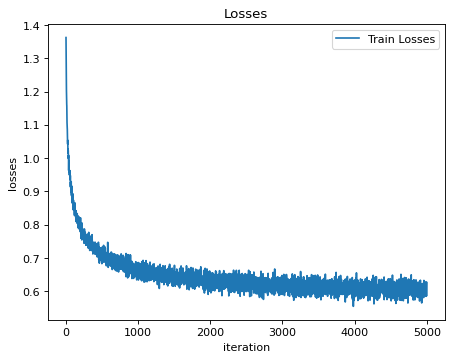

In [48]:
# same call as the class notebook; alpha is 0.1 instead of 0.001 because the gradient is now divided by m
model = LogisticRegression(k, n, "minibatch", alpha=0.1)
model.fit(X_train_arr[idx_tr], Y_train_encoded[idx_tr])
yhat_val = model.predict(X_train_arr[idx_val])
model.plot()
plt.show()
print("=========Classification report=======")
print("Report: ", classification_report(y_val, yhat_val))

## **Task 1: Classification metrics from scratch**

In [49]:
acc_score = model.accuracy(yhat_val, y_val)
print("Accuracy Score:", acc_score)

Accuracy Score: 0.7188679245283018


In [50]:
# per class: TP / FP / TN / FN -> precision, recall, f1
for c in range(k):
    TP, FP, TN, FN = model.confusion_matrix(yhat_val, y_val, c)
    print(f"For class {c}:  TP={TP}  FP={FP}  TN={TN}  FN={FN}   (sum = {TP + FP + TN + FN})")
    print("   Precision:", round(model.precision(yhat_val, y_val, c), 4))
    print("   Recall   :", round(model.recall(yhat_val, y_val, c), 4))
    print("   f1       :", round(model.f1(yhat_val, y_val, c), 4))
    print("   support  :", model.support(y_val, c))

For class 0:  TP=226  FP=38  TN=749  FN=47   (sum = 1060)
   Precision: 0.8561
   Recall   : 0.8278
   f1       : 0.8417
   support  : 273
For class 1:  TP=163  FP=106  TN=697  FN=94   (sum = 1060)
   Precision: 0.6059
   Recall   : 0.6342
   f1       : 0.6198
   support  : 257
For class 2:  TP=178  FP=110  TN=667  FN=105   (sum = 1060)
   Precision: 0.6181
   Recall   : 0.629
   f1       : 0.6235
   support  : 283
For class 3:  TP=195  FP=44  TN=769  FN=52   (sum = 1060)
   Precision: 0.8159
   Recall   : 0.7895
   f1       : 0.8025
   support  : 247


In [51]:
print("macro precision   :", model.macro_precision(yhat_val, y_val))
print("macro recall      :", model.macro_recall(yhat_val, y_val))
print("macro f1          :", model.macro_f1(yhat_val, y_val))
print("weighted precision:", model.weighted_precision(yhat_val, y_val))
print("weighted recall   :", model.weighted_recall(yhat_val, y_val))
print("weighted f1       :", model.weighted_f1(yhat_val, y_val))

macro precision   : 0.7239909246491136
macro recall      : 0.7201322555508023
macro f1          : 0.7218554553055887
weighted precision: 0.7225189517592484
weighted recall   : 0.718867924528302
weighted f1       : 0.7204908357169415


In [52]:
# our report, laid out like sklearn's
model.classification_report(yhat_val, y_val).round(4)

,precision,recall,f1-score,support
0,0.8561,0.8278,0.8417,273
1,0.6059,0.6342,0.6198,257
2,0.6181,0.6290,0.6235,283
3,0.8159,0.7895,0.8025,247
accuracy,NaN,NaN,0.7189,1060
macro avg,0.7240,0.7201,0.7219,1060
weighted avg,0.7225,0.7189,0.7205,1060


### Comparing with scikit-learn's `classification_report`
The helper below puts our numbers next to sklearn's (`output_dict=True`) and checks that they agree. It is run twice: on **mock-up data** (random labels, imbalanced like the PDF example: 20 % / 30 % / 20 % / 30 %) and on the **validation predictions** above.

In [53]:
def compare_with_sklearn(our_model, y_true, y_pred):
    ours = our_model.classification_report(y_pred, y_true)
    sk = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    rows = []
    for name in ['0', '1', '2', '3', 'macro avg', 'weighted avg']:
        for metric in ['precision', 'recall', 'f1-score']:
            rows.append([name, metric, ours.loc[name, metric], sk[name][metric]])
    rows.append(['accuracy', 'accuracy', ours.loc['accuracy', 'f1-score'], sk['accuracy']])

    table = pd.DataFrame(rows, columns=['row', 'metric', 'ours', 'sklearn'])
    table['abs diff'] = (table['ours'] - table['sklearn']).abs()
    same_support = all(ours.loc[str(c), 'support'] == sk[str(c)]['support'] for c in range(4))
    print("all metrics equal (np.allclose):", np.allclose(table['ours'], table['sklearn']))
    print("support equal                  :", same_support)
    return table

In [54]:
# mock-up data: 300 true labels with 20% / 30% / 20% / 30% classes, about 35% of the predictions made wrong at random
rng = np.random.default_rng(7)
y_true_mock = rng.choice(4, size=300, p=[0.2, 0.3, 0.2, 0.3])
y_pred_mock = y_true_mock.copy()
wrong = rng.random(300) < 0.35
y_pred_mock[wrong] = rng.choice(4, size=wrong.sum())

print(classification_report(y_true_mock, y_pred_mock))
mock_table = compare_with_sklearn(model, y_true_mock, y_pred_mock)
mock_table.round(6)

              precision    recall  f1-score   support

           0       0.67      0.71      0.69        63
           1       0.80      0.77      0.78        77
           2       0.75      0.80      0.77        69
           3       0.81      0.77      0.79        91

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.77      0.76      0.76       300

all metrics equal (np.allclose): True
support equal                  : True


,row,metric,ours,sklearn,abs diff
0,0,precision,0.671642,0.671642,0.0
1,0,recall,0.714286,0.714286,0.0
2,0,f1-score,0.692308,0.692308,0.0
3,1,precision,0.797297,0.797297,0.0
4,1,recall,0.766234,0.766234,0.0
5,1,f1-score,0.781457,0.781457,0.0
6,2,precision,0.753425,0.753425,0.0
7,2,recall,0.797101,0.797101,0.0
8,2,f1-score,0.774648,0.774648,0.0
9,3,precision,0.813953,0.813953,0.0


In [55]:
val_table = compare_with_sklearn(model, y_val, yhat_val)
val_table.round(6)

all metrics equal (np.allclose): True
support equal                  : True


,row,metric,ours,sklearn,abs diff
0,0,precision,0.856061,0.856061,0.0
1,0,recall,0.827839,0.827839,0.0
2,0,f1-score,0.841713,0.841713,0.0
3,1,precision,0.605948,0.605948,0.0
4,1,recall,0.634241,0.634241,0.0
5,1,f1-score,0.619772,0.619772,0.0
6,2,precision,0.618056,0.618056,0.0
7,2,recall,0.628975,0.628975,0.0
8,2,f1-score,0.623468,0.623468,0.0
9,3,precision,0.815900,0.815900,0.0


**Both implementations give the same numbers** (differences are 0 up to floating point), on the mock-up data and on the real validation predictions.

**Note on the weighted average in the PDF.** The weights are the class shares `support_c / total` (0.2, 0.3, 0.2, 0.3), and they already sum to 1. So the weighted precision is simply `0.2·p0 + 0.3·p1 + 0.2·p2 + 0.3·p3`. The PDF's example also divides by 4, which gives a number about 4 times too small that does not match sklearn:

In [56]:
weights = np.array([model.support(y_true_mock, c) for c in range(4)]) / len(y_true_mock)
precisions = np.array([model.precision(y_pred_mock, y_true_mock, c) for c in range(4)])
print("class shares (weights):", weights.round(3), " sum =", weights.sum())
print("weighted precision, sum(w * p)    :", round((weights * precisions).sum(), 4), "  <- ours = sklearn")
print("PDF formula, sum(w * p) / 4       :", round((weights * precisions).sum() / 4, 4))
print("sklearn 'weighted avg' precision  :",
      round(classification_report(y_true_mock, y_pred_mock, output_dict=True)['weighted avg']['precision'], 4))

class shares (weights): [0.21  0.257 0.23  0.303]  sum = 1.0
weighted precision, sum(w * p)    : 0.7659   <- ours = sklearn
PDF formula, sum(w * p) / 4       : 0.1915
sklearn 'weighted avg' precision  : 0.7659


### What does *support* in the classification report mean?
**Support is the number of samples that truly belong to each class** in the data being evaluated (`y_true`), i.e. how many times the class actually occurs. It does not depend on the predictions. In the rows `accuracy`, `macro avg` and `weighted avg` it is the total number of samples. Support tells us how much each per-class score can be trusted (a precision computed from 5 samples is shaky) and it is exactly the weight used in the **weighted average**: `weight_c = support_c / total`.

## **Task 2: Ridge Logistic Regression**

The ridge loss adds the squared weights to the cross-entropy:

$$J(\theta) = -\sum_{i=1}^{m} y^{(i)}\log(h^{(i)}) + \lambda\sum_{j=1}^{n}\theta_j^2 \qquad\Rightarrow\qquad \frac{\partial J}{\partial \theta} = \mathbf{X}^\top(\mathbf{H}-\mathbf{Y}) + 2\lambda\theta$$

* The sum starts at **j = 1**, so the intercept row (row 0 of `W`) is not penalised: `RidgePenalty.derivation` sets that row to 0.
* As in *03 - Regularization.ipynb*, the code averages the data term over the batch (÷ m) and adds the penalty as it is, so our λ equals the PDF's λ divided by m. The best weights are the same; only the scale of λ differs.
* **The user chooses:** `LogisticRegression(..., use_penalty=True, l=0.01)` or the shortcut `RidgeLogisticRegression(..., l=0.01)`. With `use_penalty=False` (default) the class is plain logistic regression.

In [57]:
plain = LogisticRegression(k, n, "batch", alpha=0.1, use_penalty=False, verbose=False)
plain.fit(X_train_arr[idx_tr], Y_train_encoded[idx_tr])

ridge = RidgeLogisticRegression(k, n, "batch", alpha=0.1, l=0.01, verbose=False)
ridge.fit(X_train_arr[idx_tr], Y_train_encoded[idx_tr])

for name, mdl in [("no penalty", plain), ("ridge, l=0.01", ridge)]:
    yhat_tr = mdl.predict(X_train_arr[idx_tr])
    yhat_v = mdl.predict(X_train_arr[idx_val])
    print(f"{name:14s}  sum of squared weights = {np.sum(mdl.W[1:] ** 2):7.2f}   "
          f"train acc = {mdl.accuracy(yhat_tr, y_train_arr[idx_tr]):.4f}   "
          f"val acc = {mdl.accuracy(yhat_v, y_val):.4f}   val macro f1 = {mdl.macro_f1(yhat_v, y_val):.4f}")

no penalty      sum of squared weights =   90.93   train acc = 0.7382   val acc = 0.7198   val macro f1 = 0.7227
ridge, l=0.01   sum of squared weights =   10.25   train acc = 0.7175   val acc = 0.7132   val macro f1 = 0.7132


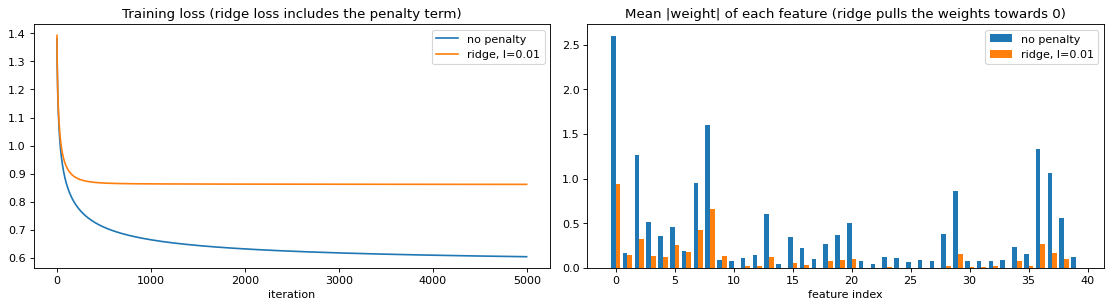

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(plain.losses, label="no penalty")
axes[0].plot(ridge.losses, label="ridge, l=0.01")
axes[0].set_title("Training loss (ridge loss includes the penalty term)")
axes[0].set_xlabel("iteration")
axes[0].legend()

axes[1].bar(np.arange(n - 1) - 0.2, np.abs(plain.W[1:]).mean(axis=1), width=0.4, label="no penalty")
axes[1].bar(np.arange(n - 1) + 0.2, np.abs(ridge.W[1:]).mean(axis=1), width=0.4, label="ridge, l=0.01")
axes[1].set_title("Mean |weight| of each feature (ridge pulls the weights towards 0)")
axes[1].set_xlabel("feature index")
axes[1].legend()

plt.tight_layout()
plt.show()

Ridge shrinks the weights (much smaller sum of squares). Here it does not improve the validation score: train and validation accuracy are close, so the plain model is **not overfitting**; its error comes from bias (a linear model on 40 features), which a penalty cannot fix. Whether a small λ helps is decided by cross-validation in the experiments below.

## **Experiments, logged to MLflow** (Task 3 – Objective 1)
* Settings compared: method {batch, minibatch, sto} × learning rate {0.1, 0.01, 0.001} × penalty {none, ridge λ = 0.001, 0.01, 0.1} = **36 runs**.
* Each run is scored with **stratified 3-fold cross-validation on the training set** (mean accuracy, macro F1, weighted F1), then refit on all training data; that refit model is saved with the run.
* Every run goes to the CSIM MLflow server: experiment **`st125973-a3`**, parameters, metrics and the model. **The dataset is not logged** (no `mlflow.log_input`, no autolog).
* The test set is still not used here.

In [59]:
import os

# ---- MLflow configuration ----
USE_MLFLOW = True                                       # False -> run the experiments without logging
MLFLOW_TRACKING_URI = "http://mlflow.ml.brain.cs.ait.ac.th/"
EXPERIMENT_NAME = "st125973-a3"
REGISTERED_MODEL_NAME = "st125973-a3-model"

# If the server asks for a login, set the credentials given in class BEFORE running this cell
# (keep real passwords out of GitHub):
# os.environ["MLFLOW_TRACKING_USERNAME"] = "..."
# os.environ["MLFLOW_TRACKING_PASSWORD"] = "..."

In [60]:
mlflow_ok = False
if USE_MLFLOW:
    try:
        import requests
        import mlflow
        from mlflow.models import infer_signature

        # 1) is the server reachable, and which version does it run?
        login = None
        if os.environ.get("MLFLOW_TRACKING_USERNAME"):
            login = (os.environ["MLFLOW_TRACKING_USERNAME"], os.environ.get("MLFLOW_TRACKING_PASSWORD", ""))
        response = requests.get(MLFLOW_TRACKING_URI.rstrip("/") + "/version", timeout=10, auth=login)
        if response.status_code == 401:
            raise PermissionError("the server needs a username/password -> set MLFLOW_TRACKING_USERNAME / PASSWORD above")
        server_version = response.text.strip()
        print("MLflow server version:", server_version, "| client (this computer):", mlflow.__version__)
        if server_version[:1].isdigit() and server_version.split(".")[0] != mlflow.__version__.split(".")[0]:
            print(f"WARNING: different major versions. If logging the model fails, run:  pip install mlflow=={server_version}")

        # 2) point MLflow at the server and choose the experiment (created if it does not exist)
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        mlflow.set_experiment(EXPERIMENT_NAME)
        mlflow_ok = True
        print("Logging to", MLFLOW_TRACKING_URI, "-> experiment", EXPERIMENT_NAME)
    except Exception as e:
        print("MLflow logging is OFF ->", type(e).__name__, ":", str(e)[:200])
        print("The experiments below still run. Connect to the AIT network / VPN and re-run to log them.")

MLflow logging is OFF -> ModuleNotFoundError : No module named 'mlflow'
The experiments below still run. Connect to the AIT network / VPN and re-run to log them.


In [61]:
from sklearn.model_selection import StratifiedKFold

methods   = ["batch", "minibatch", "sto"]
alphas    = [0.1, 0.01, 0.001]
penalties = [(False, 0.0), (True, 0.001), (True, 0.01), (True, 0.1)]   # (use_penalty, lambda) -> Task 2 option
max_iter  = 5000

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []        # one row per run
final_models = {}   # run name -> model refit on ALL training data
model_uris = {}     # run name -> where MLflow stored that model (used to register the best one)

start_all = time.time()
for method in methods:
    for alpha in alphas:
        for use_penalty, l in penalties:
            run_name = f"{method}-lr{alpha}-" + (f"ridge{l}" if use_penalty else "nopenalty")
            params = {"method": method, "alpha": alpha, "max_iter": max_iter,
                      "use_penalty": use_penalty, "lambda": l, "cv_folds": 3}

            # 1) stratified 3-fold cross-validation on the TRAINING set
            fold_acc, fold_macro_f1, fold_weighted_f1 = [], [], []
            for train_idx, val_idx in skf.split(X_train_arr, y_train_arr):
                cv_model = LogisticRegression(k, n, method, alpha=alpha, max_iter=max_iter,
                                              use_penalty=use_penalty, l=l, verbose=False)
                cv_model.fit(X_train_arr[train_idx], Y_train_encoded[train_idx])
                yhat_fold = cv_model.predict(X_train_arr[val_idx])
                y_fold = y_train_arr[val_idx]
                fold_acc.append(cv_model.accuracy(yhat_fold, y_fold))
                fold_macro_f1.append(cv_model.macro_f1(yhat_fold, y_fold))
                fold_weighted_f1.append(cv_model.weighted_f1(yhat_fold, y_fold))

            # 2) refit the same settings on ALL training data -> the model saved with this run
            final_model = LogisticRegression(k, n, method, alpha=alpha, max_iter=max_iter,
                                             use_penalty=use_penalty, l=l, verbose=False)
            final_model.fit(X_train_arr, Y_train_encoded)
            final_models[run_name] = final_model
            yhat_train = final_model.predict(X_train_arr)

            metrics = {"cv_accuracy": float(np.mean(fold_acc)),
                       "cv_accuracy_std": float(np.std(fold_acc)),
                       "cv_macro_f1": float(np.mean(fold_macro_f1)),
                       "cv_weighted_f1": float(np.mean(fold_weighted_f1)),
                       "train_accuracy": float(final_model.accuracy(yhat_train, y_train_arr)),
                       "final_train_loss": float(final_model.losses[-1])}
            row = {"run_name": run_name, **params, **metrics}

            # 3) log params, metrics and the model to MLflow (the dataset is NOT logged)
            if mlflow_ok:
                try:
                    with mlflow.start_run(run_name=run_name) as run:
                        mlflow.log_params(params)
                        mlflow.log_metrics(metrics)
                        signature = infer_signature(X_train_arr, yhat_train)
                        model_info = mlflow.sklearn.log_model(
                            final_model, artifact_path="model", signature=signature,
                            serialization_format="cloudpickle",
                            pip_requirements=["numpy", "pandas", "scikit-learn", "cloudpickle"])
                        model_uris[run_name] = model_info.model_uri
                        row["run_id"] = run.info.run_id
                except Exception as e:
                    mlflow_ok = False      # stop logging, but finish the experiments
                    print("MLflow logging failed and is now OFF ->", type(e).__name__, ":", str(e)[:300])
                    print("Tip: install the server's MLflow version printed above (pip install mlflow==...) and re-run.")

            results.append(row)
            print(f"{run_name:26s} cv_acc = {metrics['cv_accuracy']:.4f}   cv_macro_f1 = {metrics['cv_macro_f1']:.4f}"
                  f"   train_acc = {metrics['train_accuracy']:.4f}")

print(f"\n{len(results)} runs in {time.time() - start_all:.0f}s")

batch-lr0.1-nopenalty      cv_acc = 0.7321   cv_macro_f1 = 0.7340   train_acc = 0.7385
batch-lr0.1-ridge0.001     cv_acc = 0.7274   cv_macro_f1 = 0.7292   train_acc = 0.7385
batch-lr0.1-ridge0.01      cv_acc = 0.7087   cv_macro_f1 = 0.7079   train_acc = 0.7192
batch-lr0.1-ridge0.1       cv_acc = 0.6402   cv_macro_f1 = 0.6165   train_acc = 0.6426
batch-lr0.01-nopenalty     cv_acc = 0.7121   cv_macro_f1 = 0.7123   train_acc = 0.7166
batch-lr0.01-ridge0.001    cv_acc = 0.7108   cv_macro_f1 = 0.7109   train_acc = 0.7158
batch-lr0.01-ridge0.01     cv_acc = 0.7040   cv_macro_f1 = 0.7020   train_acc = 0.7117
batch-lr0.01-ridge0.1      cv_acc = 0.6342   cv_macro_f1 = 0.6056   train_acc = 0.6347
batch-lr0.001-nopenalty    cv_acc = 0.6151   cv_macro_f1 = 0.5997   train_acc = 0.6143
batch-lr0.001-ridge0.001   cv_acc = 0.6155   cv_macro_f1 = 0.5999   train_acc = 0.6142
batch-lr0.001-ridge0.01    cv_acc = 0.6134   cv_macro_f1 = 0.5956   train_acc = 0.6158
batch-lr0.001-ridge0.1     cv_acc = 0.6115 

In [62]:
results_df = pd.DataFrame(results).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
results_df["penalty"] = np.where(results_df["use_penalty"], "ridge l=" + results_df["lambda"].astype(str), "none")
show_cols = ["run_name", "method", "alpha", "penalty", "cv_accuracy", "cv_accuracy_std",
             "cv_macro_f1", "cv_weighted_f1", "train_accuracy"]
results_df[show_cols].head(12).round(4)

,run_name,method,alpha,penalty,cv_accuracy,cv_accuracy_std,cv_macro_f1,cv_weighted_f1,train_accuracy
0,minibatch-lr0.1-nopenalty,minibatch,0.10,none,0.7341,0.0071,0.7364,0.7352,0.7374
1,batch-lr0.1-nopenalty,batch,0.10,none,0.7321,0.0084,0.7340,0.7327,0.7385
2,batch-lr0.1-ridge0.001,batch,0.10,ridge l=0.001,0.7274,0.0077,0.7292,0.7280,0.7385
3,minibatch-lr0.1-ridge0.001,minibatch,0.10,ridge l=0.001,0.7270,0.0098,0.7291,0.7281,0.7370
4,batch-lr0.01-nopenalty,batch,0.01,none,0.7121,0.0084,0.7123,0.7116,0.7166
5,minibatch-lr0.01-nopenalty,minibatch,0.01,none,0.7106,0.0083,0.7109,0.7103,0.7168
6,batch-lr0.01-ridge0.001,batch,0.01,ridge l=0.001,0.7108,0.0084,0.7109,0.7102,0.7158
7,minibatch-lr0.01-ridge0.001,minibatch,0.01,ridge l=0.001,0.7087,0.0085,0.7088,0.7082,0.7158
8,batch-lr0.1-ridge0.01,batch,0.10,ridge l=0.01,0.7087,0.0119,0.7079,0.7074,0.7192
9,minibatch-lr0.1-ridge0.01,minibatch,0.10,ridge l=0.01,0.7058,0.0140,0.7043,0.7041,0.7226


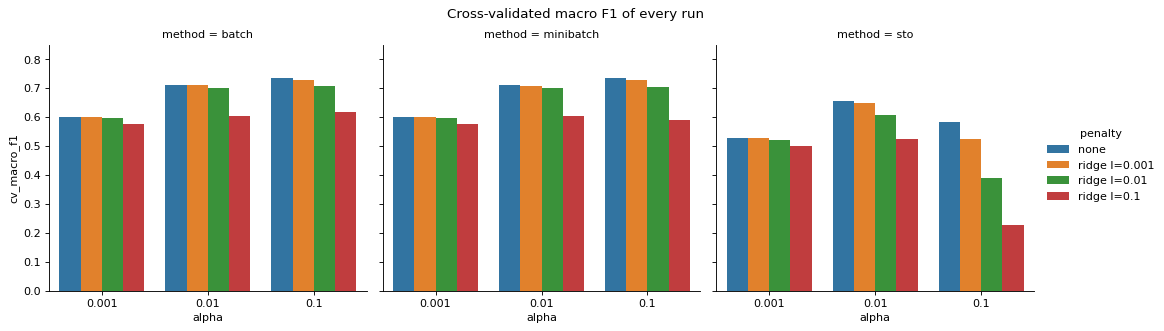

In [63]:
g = sns.catplot(data=results_df, x="alpha", y="cv_macro_f1", hue="penalty", col="method",
                kind="bar", height=4, aspect=1.1, col_order=["batch", "minibatch", "sto"],
                hue_order=["none", "ridge l=0.001", "ridge l=0.01", "ridge l=0.1"])
g.set(ylim=(0, 0.85))
g.figure.suptitle("Cross-validated macro F1 of every run", y=1.03)
plt.show()

**What the experiments show** (all numbers are cross-validated on the training set):
* **The learning rate matters most.** With α = 0.1, batch and minibatch reach a CV macro F1 of about 0.73–0.74; with α = 0.01 about 0.71; with α = 0.001 only about 0.60, because 5000 small steps are not enough to reach the minimum (the loss is still going down).
* **Batch vs minibatch:** practically the same scores (0.734 vs 0.736). Minibatch uses 30 % of the rows per step, so every step is cheaper, at no cost in quality; its loss curve is just noisier.
* **Stochastic** (one row per step) is clearly worse (best 0.655 at α = 0.01). 5000 one-row updates are only about 1.4 passes over the data, and every step follows the gradient of a single car, so the weights keep jumping; with α = 0.1 the jumps are too big (0.58).
* **Ridge (Task 2):** λ = 0.001 changes almost nothing (−0.005), λ = 0.01 costs about 0.03 and λ = 0.1 about 0.12–0.15. The penalty pulls the weights towards 0 and the model **underfits**. Train accuracy (≈ 0.74) and CV accuracy (≈ 0.73) are almost the same, so the plain model is not overfitting and there is nothing for ridge to fix: the error comes from bias (a linear model), not variance. With 5300 cars and only 41 × 4 weights, the data alone keeps the weights stable.
* **Best run: `minibatch-lr0.1-nopenalty`** (CV macro F1 0.736, CV accuracy 0.734); `batch-lr0.1-nopenalty` is a practically equal second (0.734).

## Final model: refit on all training data, evaluated **once** on the test set

In [64]:
best = results_df.iloc[0]
best_name = best["run_name"]
best_model = final_models[best_name]       # already refit on ALL training data inside the loop

print("Best run (chosen by cross-validated macro F1 - the test set was not used to choose):", best_name)
best[["method", "alpha", "use_penalty", "lambda", "cv_accuracy", "cv_macro_f1", "train_accuracy"]]

Best run (chosen by cross-validated macro F1 - the test set was not used to choose): minibatch-lr0.1-nopenalty


method            minibatch
alpha                   0.1
use_penalty           False
lambda                  0.0
cv_accuracy        0.734149
cv_macro_f1        0.736447
train_accuracy     0.737358
Name: 0, dtype: object

In [65]:
# ---- the only time the test set is used ----
yhat_test = best_model.predict(X_test_arr)

print("=========Our classification report (test set)=======")
best_model.classification_report(yhat_test, y_test_arr).round(4)

=========Our classification report (test set)=======


,precision,recall,f1-score,support
0,0.8765,0.8534,0.8648,341
1,0.6718,0.6801,0.6759,322
2,0.6546,0.7175,0.6846,354
3,0.8607,0.7799,0.8183,309
accuracy,NaN,NaN,0.7579,1326
macro avg,0.7659,0.7577,0.7609,1326
weighted avg,0.7639,0.7579,0.7600,1326


In [66]:
print("=========sklearn classification report (test set)=======")
print(classification_report(y_test_arr, yhat_test, digits=4))
test_table = compare_with_sklearn(best_model, y_test_arr, yhat_test)

=========sklearn classification report (test set)=======
              precision    recall  f1-score   support

           0     0.8765    0.8534    0.8648       341
           1     0.6718    0.6801    0.6759       322
           2     0.6546    0.7175    0.6846       354
           3     0.8607    0.7799    0.8183       309

    accuracy                         0.7579      1326
   macro avg     0.7659    0.7577    0.7609      1326
weighted avg     0.7639    0.7579    0.7600      1326

all metrics equal (np.allclose): True
support equal                  : True


In [67]:
test_metrics = {"test_accuracy": float(best_model.accuracy(yhat_test, y_test_arr)),
                "test_macro_precision": float(best_model.macro_precision(yhat_test, y_test_arr)),
                "test_macro_recall": float(best_model.macro_recall(yhat_test, y_test_arr)),
                "test_macro_f1": float(best_model.macro_f1(yhat_test, y_test_arr)),
                "test_weighted_precision": float(best_model.weighted_precision(yhat_test, y_test_arr)),
                "test_weighted_recall": float(best_model.weighted_recall(yhat_test, y_test_arr)),
                "test_weighted_f1": float(best_model.weighted_f1(yhat_test, y_test_arr))}
print(pd.Series(test_metrics).round(4))

# the test scores are added to the BEST run only (they were not used to choose it)
if mlflow_ok:
    with mlflow.start_run(run_id=best["run_id"]):
        mlflow.log_metrics(test_metrics)
        mlflow.set_tag("best_model", "true")
    print("test metrics logged to run", best["run_id"])

test_accuracy              0.7579
test_macro_precision       0.7659
test_macro_recall          0.7577
test_macro_f1              0.7609
test_weighted_precision    0.7639
test_weighted_recall       0.7579
test_weighted_f1           0.7600
dtype: float64


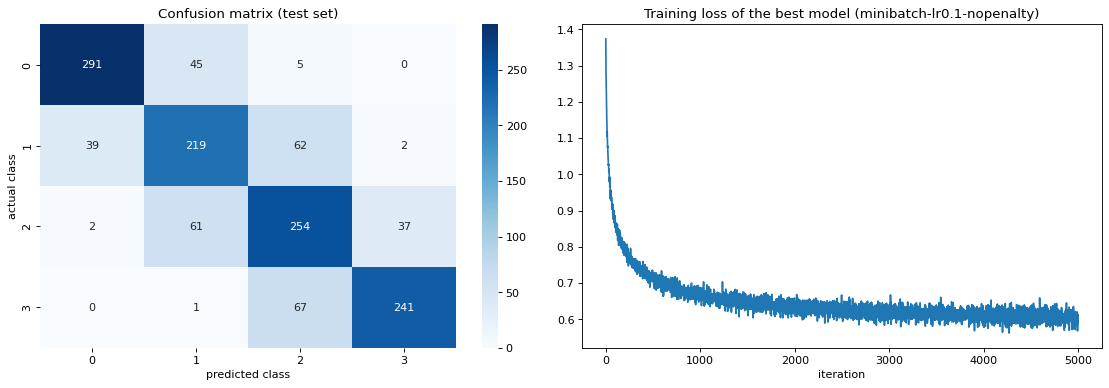

In [68]:
# full confusion matrix: rows = actual class, columns = predicted class
cm = np.zeros((k, k), dtype=int)
for actual, predicted in zip(y_test_arr, yhat_test):
    cm[actual, predicted] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_xlabel("predicted class")
axes[0].set_ylabel("actual class")
axes[0].set_title("Confusion matrix (test set)")

axes[1].plot(best_model.losses)
axes[1].set_title(f"Training loss of the best model ({best_name})")
axes[1].set_xlabel("iteration")
plt.tight_layout()
plt.show()

**Test set (used once):** accuracy **0.758**, macro F1 **0.761**, weighted F1 **0.760**. This is close to the CV estimate (0.734 / 0.736), so the model generalises as expected (a ±2 % difference is normal for 1326 cars). Our report and sklearn's are identical on the test set too.
* Classes **0** (cheapest) and **3** (most expensive) are the easiest (F1 0.86 and 0.82). The middle classes **1** and **2** are harder (F1 ≈ 0.68) because they have a neighbouring class on both sides.
* Almost every mistake is a **neighbouring class** (0↔1, 1↔2, 2↔3): only 10 of the 321 mistakes skip a class, and a class-0 car is never predicted as class 3 or the other way round. The model has learned the order of the prices although it treats the classes as plain labels.

### Feature importance
The features are standardised (or 0/1), so the size of a weight shows how strongly a feature moves the class scores. Importance of a feature = mean |weight| over the 4 classes (intercept excluded).

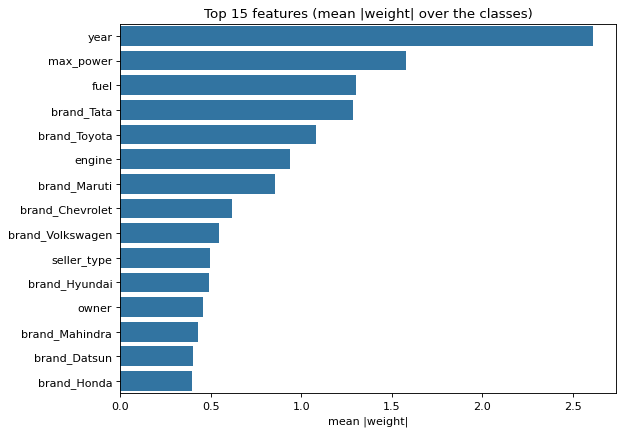

,class 0,class 1,class 2,class 3
year,-3.767,-1.356,1.214,4.102
max_power,-2.393,-0.844,0.694,2.388
fuel,-1.650,-0.933,0.253,2.373
brand_Tata,2.060,0.545,-0.482,-2.066
brand_Toyota,-1.466,-0.779,0.127,1.953


In [69]:
importance = pd.Series(np.abs(best_model.W[1:]).mean(axis=1), index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importance.head(15).values, y=importance.head(15).index)
plt.title("Top 15 features (mean |weight| over the classes)")
plt.xlabel("mean |weight|")
plt.ylabel("")
plt.show()

# sign of the weights for the top 5 features in each class: + pushes a car towards that class
pd.DataFrame(best_model.W[1:], index=feature_names, columns=[f"class {c}" for c in range(k)]).loc[importance.index[:5]].round(3)

* **year** is by far the strongest feature: its weight goes from −3.8 (class 0) to +4.1 (class 3), so newer cars land in more expensive classes. Then come **max_power**, **fuel** (Diesel = 1 → more expensive) and **engine**, which matches the EDA.
* **Brands** adjust the price *for the same year and power*: Tata, Chevrolet, Mahindra and Datsun push towards the cheaper classes; Toyota, Maruti, Honda and Hyundai (brands that keep their resale value) towards the more expensive ones. Luxury brands (BMW, Mercedes-Benz, Audi) get small weights: there are few of them, and their high prices are already explained by year, max_power and engine.
* More previous owners (`owner`) and a manual gearbox (`transmission = 1`) push away from class 3.

## Export for the app (inference)
The web app must turn a raw car into **exactly the same 41 numbers** the model was trained on. Everything that was *learned from the training set* is therefore exported together with the weights into `app/model/car_price_a3.json`: the mappings, the `LabelEncoder` classes, the `OneHotEncoder` brands, the `StandardScaler` mean/scale, the training defaults and the price-class edges. JSON (not pickle) keeps the file readable and independent of the Python / library versions inside the Docker image.

In [70]:
import json

bundle = {
    "model_name": REGISTERED_MODEL_NAME,
    "best_run": best_name,
    "hyperparameters": {"method": best["method"], "alpha": float(best["alpha"]), "max_iter": int(best["max_iter"]),
                        "use_penalty": bool(best["use_penalty"]), "lambda": float(best["lambda"])},
    "W": best_model.W.tolist(),                                    # (41, 4), row 0 = intercept
    "k": int(k),
    "feature_columns": feature_names,                              # encoded column order
    "scale_columns": scal_col,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "owner_mapping": owner_mapping,
    "transmission_mapping": transmission_mapping,
    "fuel_mapping": fuel_mapping,
    "seller_type_classes": seller_type_le.classes_.tolist(),
    "brand_categories": brandOneEncoder.categories_[0].tolist(),
    "defaults": train_defaults,
    "price_bins": [float(b) for b in selling_price_bins],
    "test_metrics": test_metrics,
}

os.makedirs(os.path.join("app", "model"), exist_ok=True)
bundle_path = os.path.join("app", "model", "car_price_a3.json")
with open(bundle_path, "w", encoding="utf-8") as f:
    json.dump(bundle, f, indent=2)
print("saved", bundle_path, f"({os.path.getsize(bundle_path) / 1024:.1f} KB)")

saved app/model/car_price_a3.json (7.7 KB)


In [71]:
# Check: the app's code (app/code/car_price_model.py) + the exported file must reproduce this notebook.
# It starts from the RAW test cars (strings like 'Diesel', 'First Owner', 'Maruti') and does its own preprocessing.
import sys
sys.path.insert(0, os.path.join("app", "code"))
from car_price_model import CarPriceModel

app_model = CarPriceModel(bundle_path)
app_pred = app_model.predict(X_test_raw)
print("app predictions == notebook predictions on all", len(app_pred), "test cars:", np.array_equal(app_pred, yhat_test))

app predictions == notebook predictions on all 1326 test cars: True


In [72]:
# inference on one new car, exactly what the web app does
sample_car = {"year": 2017, "km_driven": 40000, "fuel": "Diesel", "seller_type": "Individual",
              "transmission": "Manual", "owner": "First Owner", "mileage": 21.5, "engine": 1248,
              "max_power": 74.0, "seats": 5, "brand": "Maruti"}
app_model.predict_one(sample_car)

{'price_class': 3, 'price_range': 'above ₹ 650,000', 'probabilities': [0.0004465902711072243, 0.04224832073174873, 0.40060379270999064, 0.5567012962871534]}

## Register the best model (Task 3 – Objective 2)
The best run's model is registered as **`st125973-a3-model`** and moved to **Staging**. The cell does it from code; the same can be done in the MLflow UI:
1. Open http://mlflow.ml.brain.cs.ait.ac.th/ → *Experiments* → `st125973-a3`, sort the runs by `cv_macro_f1` (the best run also has the tag `best_model = true` and the `test_*` metrics).
2. Open the run → *Artifacts* → `model` → **Register model** → *Create new model* → name `st125973-a3-model`.
3. *Models* → `st125973-a3-model` → the new version → **Stage: Staging** (newer MLflow versions show *aliases* instead of stages; the cell also sets the alias `staging`).

In [73]:
if mlflow_ok:
    from mlflow.tracking import MlflowClient
    client = MlflowClient()

    registered = mlflow.register_model(model_uris[best_name], REGISTERED_MODEL_NAME)
    print("registered", registered.name, "version", registered.version)

    try:
        client.transition_model_version_stage(name=REGISTERED_MODEL_NAME, version=registered.version, stage="Staging")
        print("version", registered.version, "-> Staging")
    except Exception as e:
        print("Could not set the stage from code (set it in the UI):", type(e).__name__, str(e)[:150])

    try:
        client.set_registered_model_alias(REGISTERED_MODEL_NAME, "staging", registered.version)
        print("alias 'staging' ->", registered.version)
    except Exception as e:
        print("alias not set:", type(e).__name__, str(e)[:150])
else:
    print("MLflow is OFF in this run -> register the model after re-running on the AIT network (or use the UI steps above).")

MLflow is OFF in this run -> register the model after re-running on the AIT network (or use the UI steps above).


## Task 3 – Objective 3: CI/CD
* **Unit tests** – `app/tests/test_model.py` loads the exported model and checks that (1) it takes the expected input (a raw car becomes a `(1, 41)` array that the model accepts) and (2) the output has the expected shape (`(m,)` classes in {0, 1, 2, 3} and `(m, 4)` probabilities that sum to 1).
* **GitHub Actions** – `.github/workflows/ci-cd.yml`: every push to `main` installs the requirements and runs `pytest`; **only if the tests pass**, the `deploy` job connects to the course VM over SSH, pulls the new commit and rebuilds / restarts the Docker container (`docker compose up -d --build` in `app/`).
* The steps to set the GitHub secrets (`SSH_HOST`, `SSH_USER`, `SSH_PRIVATE_KEY`) and run everything are in `README.md`.

## Conclusion
* **Task 1** – accuracy, per-class precision / recall / F1, macro and weighted averages are methods of the class and give exactly sklearn's numbers (mock-up, validation and test data). *Support* is the number of true samples of each class and is the weight of the weighted average (which therefore must not be divided by 4 again).
* **Task 2** – ridge is an option of the same class (`use_penalty`, `l`) or the `RidgeLogisticRegression` subclass; the intercept is not penalised. On this dataset the penalty shrinks the weights but lowers the scores slightly, because the plain model does not overfit (train ≈ CV accuracy).
* **Experiments** – 36 runs, cross-validated and logged to MLflow. The learning rate was the most important setting; minibatch with α = 0.1 and no penalty was the best (CV macro F1 0.736) and scored **0.758 accuracy / 0.761 macro F1** on the untouched test set.
* **Task 3** – the best model is registered as `st125973-a3-model` (Staging) and exported together with its fitted encoders and scaler for the Dash app in `app/`, which is unit-tested, containerised and deployed by GitHub Actions only after the tests pass.